# Verify Generalization on Non-Affine Targets

In [1]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

/Users/amandawang/Documents/thesis/01_code/concept_generalization.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_weights = torch.load("weights/" + folder + 

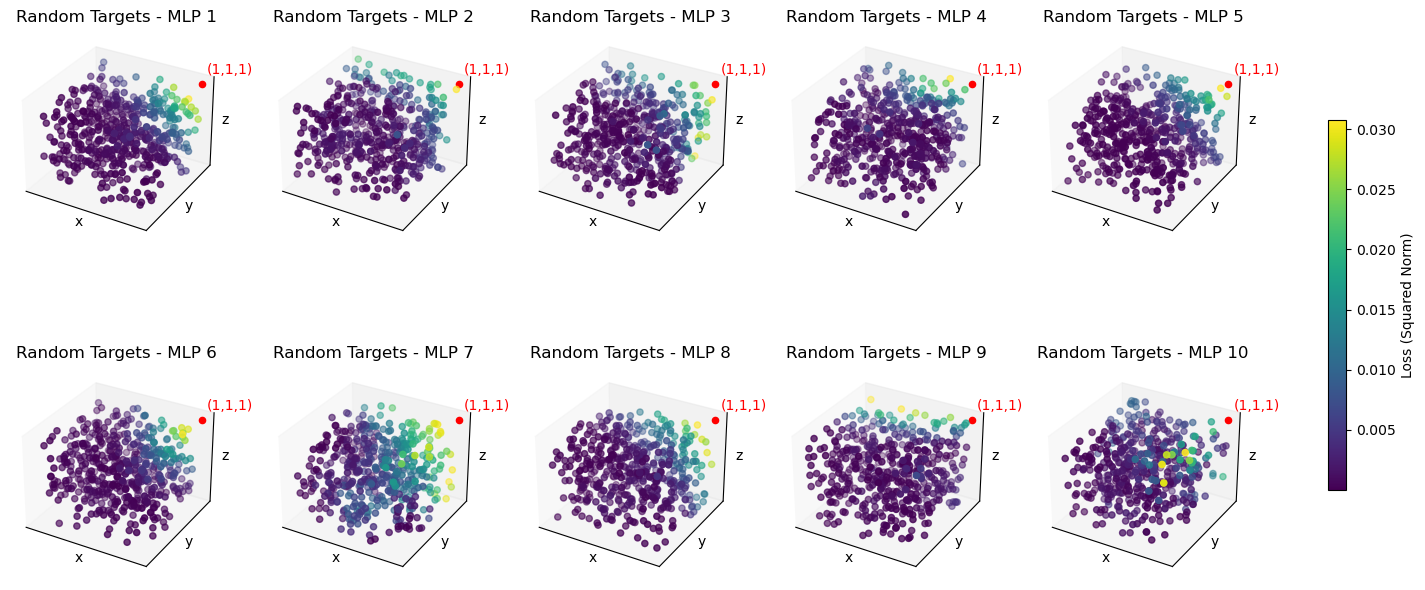

In [2]:
input_dim = 3
hidden_dims = [128]
fig = plt.figure(figsize=(20, 8))
scatter_plots = []

for m in range(10):
    # Load MLP trained on {000, 001, 010, 100}
    trained_mlp = MLP(input_dim, hidden_dims, use_init="pretrained", folder="he_identity_adam", m=m)
    trained_mlp.eval()
    # Generate random targets uniformly from {0,1}^3
    test_points = np.random.uniform(0, 1, (500, 3))
    with torch.no_grad():
        preds = trained_mlp(torch.Tensor(test_points)).numpy()
    #print(preds.shape)
    losses = [np.square(np.linalg.norm(pred - test_point)) for pred, test_point in zip(preds, test_points)]

    # Create figure and 3D axis
    ax = fig.add_subplot(2, 5, m + 1, projection='3d')

    # Plot 3D scatter with color mapping
    sc = ax.scatter(test_points[:,0], test_points[:,1], test_points[:,2], c=losses, cmap='viridis')
    scatter_plots.append(sc)

    # Add red point at (1, 1, 1)
    ax.scatter([1], [1], [1], color='red', s=20, label='(1,1,1)')  # s = marker size
    ax.text(1.02, 1.05, 1.1, "(1,1,1)", color='red')

    # Optionally, add a color bar
    #plt.colorbar(sc, ax=ax, label='Loss (Squared Norm)')

    # Set titles and labels
    ax.set_title(f"Random Targets - MLP {m + 1}")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel('x', labelpad=-15)
    ax.set_ylabel('y', labelpad=-15)
    ax.set_zlabel('z', labelpad=-15)

# Add shared color bar
cbar = fig.colorbar(scatter_plots[0], ax=fig.axes, shrink=0.6, orientation='vertical')
cbar.set_label('Loss (Squared Norm)')

plt.savefig("outputs/he_identity_adam/128/random_targets.png", bbox_inches='tight')
plt.show()